# Notebook 2 : Exploratory Data Analysis (EDA) 

In this notebook, we will analyze the data of our asset (TICKER=AAPL). We will focus particularly on the distribution of its daily returns (searching for normality and asymmetry), the study of rolling volatility to delineate market regimes, as well as an exploratory correlation matrix of our primary technical indicators.

To better understand our data and its underlying patterns, we will perform an Exploratory Data Analysis (EDA) focused on the following key aspects:

**1. Global Trends & Price Action**
- Adjusted closing prices evolution of the given TICKER over time.
- Simple Moving Averages (SMA) to identify macro trends (20-day, 50-day, and 200-day).

**2. Return Distributions**
- Daily returns distribution (histogram and density plots).
- Kurtosis and Skewness analysis to identify non-normal behaviors and "fat tails" (extreme market events).

**3. Volatility**
- Rolling volatility to detect market regimes (calm vs. crisis periods).
- Bollinger Bands to visualize price divergence and mean reversion thresholds.

**4. Volume vs. Price Analysis**
- Daily trading volume.
- Relationship between volume spikes and significant upward/downward price movements.

**5. Correlation Analysis**
- Correlation Heatmap to detect multicollinearity among our predictive variables.
- Feature-to-Target correlation to identify which technical indicators have the highest predictive power for upcoming returns.




# 1 Global Trends & Price Action

In this part we will : 
- Plot Adjusted closing prices evolution of the given TICKER over time.
- Plot Simple Moving Averages (SMA) to identify macro trends (20-day, 50-day, and 200-day).

First, we need to extract our data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

try:
    base_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    current_dir = os.getcwd()
    base_dir = os.path.dirname(current_dir)
if base_dir not in sys.path:
    sys.path.append(base_dir)
    
from helpers import csv_file as cf

df = cf.loadcsv()
print(df.head())




[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'guce.yahoo.com\', port=443): Max retries exceeded with url: /consent (Caused by NameResolutionError("HTTPSConnection(host=\'guce.yahoo.com\', port=443): Failed to resolve \'guce.yahoo.com\' ([Errno 8] nodename nor servname provided, or not known)"))'))


SystemExit: No data received

/Users/robincrifo/.local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### 1 Adjusted Closing price

No we plot the Adjusted Closing price for the period : 

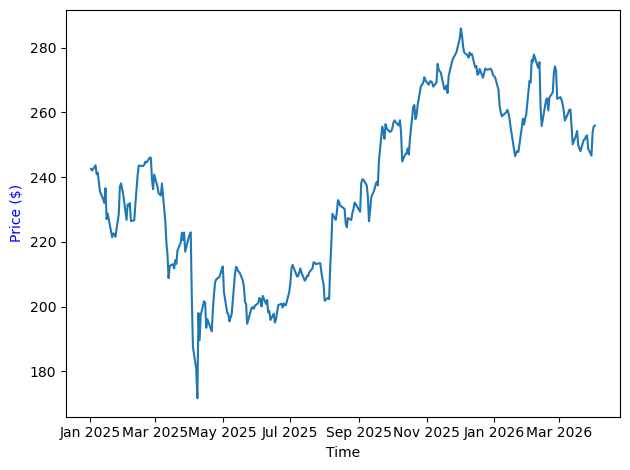

In [ ]:
import matplotlib.dates as mdates
df["Date"] = pd.to_datetime(df["Date"])
x = df["Date"]
y = df["AdjClose"]

plt.xlabel("Time", )
plt.ylabel("Price ($)", color="blue")
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.plot(x,y)
plt.tight_layout()
plt.show()

We observe several points :

- Firstly, out curb evolve between 170$ and 290$ between january 2025 and March 2026.

The minimum global was reached on May 2025 during the ... crisis which has destabilized stock market.

The maximum was reached on December 2026 because of the ...

### 2 Simple Moving Average (20 days, 50 days, 200 days)

The objective of these 3 curbs is to understand the tendances and to go further in the understanding of the value

NameError: name 'START' is not defined

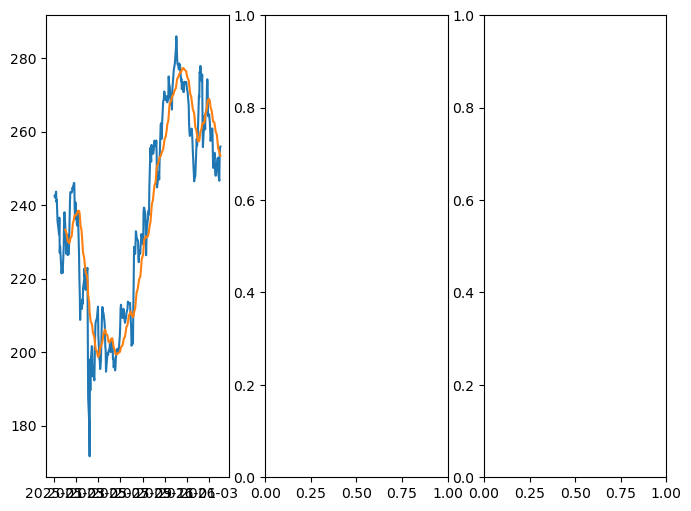

In [ ]:
df["MA20"] = df["AdjClose"].rolling(20).mean()
df["MA50"] = df["AdjClose"].rolling(50).mean()
df["MA100"] = df["AdjClose"].rolling(100).mean()

fig, axs = plt.subplots(1, 3, figsize=(8, 6))

mas = [df["MA20"], df["MA50"], df["MA100"]]
labels = ["MA20", "MA50", "MA100"]

for i, ax in enumerate(axs):
    ax.plot(x, df["AdjClose"], label="AdjClose")
    ax.plot(x, mas[i], label=labels[i])
    ax.set_title(f"Between {START} and {END}")
    ax.set_xlabel("TIME")
    ax.set_ylabel("Price ($)")
    ax.legend()

plt.tight_layout()
plt.show()






plt.tight_layout()
plt.show()